# MWE: choosing the regularisation from the evidence

Every regularised reconstruction has knobs: a weight for maximum entropy, or σ and ℓ for a Gaussian-process prior. The L-curve's corner and the discrepancy principle (χ² per point = 1) choose them from the fit to the data alone. The Bayesian evidence, the probability of the data with the regulariser integrated over, is a third criterion. It is the one used by MacKay's evidence framework and by Gull and Skilling's "classic MaxEnt".

virgil has two evidence-based criteria:
- **`imaging.log_evidence(model, data)`:** the Laplace-approximated evidence of a fit with a `GaussianField` image, at its MAP. Compare it across σ and ℓ, and keep the largest.
- **`LCurve.classic_maxent(data)`:** the maximum-entropy weight at which −2wS equals the number of well-measured directions in the image, the stationary point of the evidence in w.

Both use the Gauss–Newton curvature of the data, computed exactly. This notebook applies them to the two-night VLTI scene used in the other long-baseline MWEs, where the truth is known. You should come away knowing how to choose the hyperparameters from the evidence, and how that compares with the discrepancy principle.

In [1]:
import sys
from pathlib import Path

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
sys.path.insert(0, str(root / "src"))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as onp
import numpyro.distributions as dist
from tqdm.auto import tqdm

from virgil.coverage import vlti_oidata
from virgil.fields import GaussianField
from virgil.fitting import fit
from virgil.imaging import MaxEntropy, beam, field_of_view, image_priors, l_curve, log_evidence, starting_image
from virgil.models import GaussianDisk, Image, PointSource, System
from virgil.plotting import plot_model, plot_residual_map
from virgil.scenes import gaussian_blob, ring
from virgil.spectra import PowerLaw

templates = [vlti_oidata(hour_angles_h=(-3.0, -1.5, 0.0, 1.5, 3.0)), vlti_oidata(hour_angles_h=(-2.25, -0.75, 0.75, 2.25))]
fov, npix = field_of_view(templates[0]), 40
scale = fov / npix
truth_image = 0.8 * ring(npix, scale, 6.0, 1.0, inc_deg=50.0, pa_deg=30.0, asymmetry=0.4, asymmetry_pa_deg=90.0) + 0.2 * gaussian_blob(npix, scale, 0.5, dra=-7.0, ddec=5.0)
truth_image = truth_image / truth_image.sum()
truth = System(star=PointSource(), env=Image.from_brightness(truth_image, scale, flux=PowerLaw(0.5, 2.0, 3.5e-6)))
nights = [t.with_model(truth, key=jax.random.PRNGKey(k)) for k, t in enumerate(templates)]
start = starting_image(nights, hole_mas=0.5 * beam(nights).minor_mas)
n, h = start.env.log_brightness.shape[0], start.env.pixel_scale_mas
template = onp.asarray(GaussianDisk(4.0).render(n, n * h))
spectrum_priors = {"env.flux.ratio": dist.LogUniform(1e-2, 5.0), "env.flux.index": dist.Uniform(-6.0, 6.0)}


def ncc(a, b):
    a, b = a - a.mean(), b - b.mean()
    return float(jnp.sum(a * b) / jnp.sqrt(jnp.sum(a * a) * jnp.sum(b * b)))


print(f"{sum(d.vis.size + d.phi.size for d in nights)} data; {n}² pixels of {h:.2f} mas; beam {beam(nights).major_mas:.1f} × {beam(nights).minor_mas:.1f} mas")

990 data; 41² pixels of 0.59 mas; beam 7.0 × 3.8 mas


## The evidence over σ and ℓ

A GP image is fitted at each point of a grid in σ and ℓ, by Levenberg–Marquardt as in the Gaussian-field MWE, and `log_evidence` is evaluated at each MAP. The left panel shows the evidence relative to its maximum; the right panel shows each fit's NCC against the truth, which a real analysis would not have. The cross marks the evidence's choice.

ℓ:   0%|          | 0/4 [00:00<?, ?it/s]

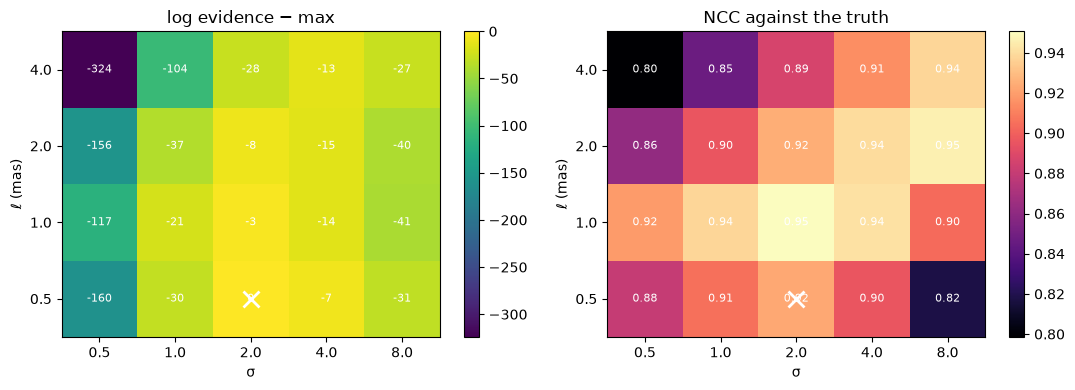

In [2]:
lengths, sigmas = [0.5, 1.0, 2.0, 4.0], [0.5, 1.0, 2.0, 4.0, 8.0]
log_z, fidelity, gp = onp.zeros((4, 5)), onp.zeros((4, 5)), {}
for i, length in enumerate(tqdm(lengths, desc="ℓ")):
    for j, sigma in enumerate(sigmas):
        field = GaussianField(onp.zeros((n, n)), sigma, length, mean=template)
        scene = System(star=PointSource(), env=Image(field, h, support=start.env.support, flux=PowerLaw(float(start.env.flux), 0.0, 3.5e-6)))
        gp[i, j] = fit(scene, image_priors(scene) | spectrum_priors, nights)
        log_z[i, j] = log_evidence(gp[i, j].model, nights)
        fidelity[i, j] = ncc(gp[i, j].model.env.render(npix, fov), truth_image)
best = onp.unravel_index(onp.argmax(log_z), log_z.shape)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, values, title, cmap in [(axes[0], log_z - log_z.max(), "log evidence − max", "viridis"), (axes[1], fidelity, "NCC against the truth", "magma")]:
    im = ax.imshow(values, origin="lower", cmap=cmap, aspect="auto")
    ax.set(xticks=range(5), xticklabels=sigmas, yticks=range(4), yticklabels=lengths, xlabel="σ", ylabel="ℓ (mas)", title=title)
    ax.plot(best[1], best[0], "wx", ms=12, mew=2)
    for (a, b), value in onp.ndenumerate(values):
        ax.text(b, a, f"{value:.0f}" if values is not fidelity else f"{value:.2f}", ha="center", va="center", color="w", fontsize=8)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Classic MaxEnt along the maximum-entropy L-curve

A maximum-entropy L-curve is swept as in the long-baseline MWE, and three criteria pick a weight from it: classic MaxEnt, the discrepancy principle and the corner. The plot shows the NCC of every fit in the sweep against the truth, with the three choices marked. Every fit in the sweep converges; much weaker weights (w ≲ 1) need far more L-BFGS steps and are of no interest here.

/var/tmp/jobfs/virgil/src/virgil/imaging.py:1252: RuntimeWarning: fit(method='lbfgs') did not converge in 50000 steps, the step limit; raise max_steps.
  result = fit(


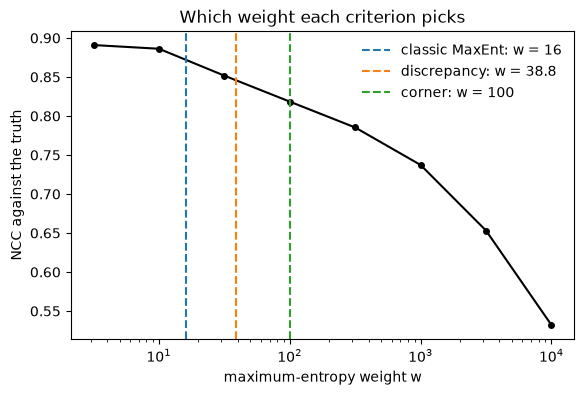

In [3]:
mem_start = start.set("env.flux", PowerLaw(start.env.flux, 0.0, 3.5e-6))
mem_priors = image_priors(mem_start) | spectrum_priors
curve = l_curve(mem_start, mem_priors, nights, MaxEntropy(1.0, path="env"), jnp.logspace(0.5, 4, 8), max_steps=50_000)
choices = {"classic MaxEnt": curve.classic_maxent(nights), "discrepancy": curve.discrepancy(), "corner": curve.corner()}

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(curve.weights, [ncc(r.model.env.render(npix, fov), truth_image) for r in curve.results], "ko-", ms=4)
for (name, weight), colour in zip(choices.items(), ("C0", "C1", "C2")):
    ax.axvline(weight, color=colour, ls="--", label=f"{name}: w = {weight:.3g}")
ax.set(xscale="log", xlabel="maximum-entropy weight w", ylabel="NCC against the truth", title="Which weight each criterion picks")
ax.legend(frameon=False)
plt.show()

## The chosen images

Here are the GP image at the evidence's choice of σ and ℓ, and the maximum-entropy images at the classic-MaxEnt and discrepancy weights, each refitted at exactly that weight from the nearest fit in the sweep. They are shown with the beam, and below them are their signed differences from the truth; these are MAP images, so the differences are not z-scores.

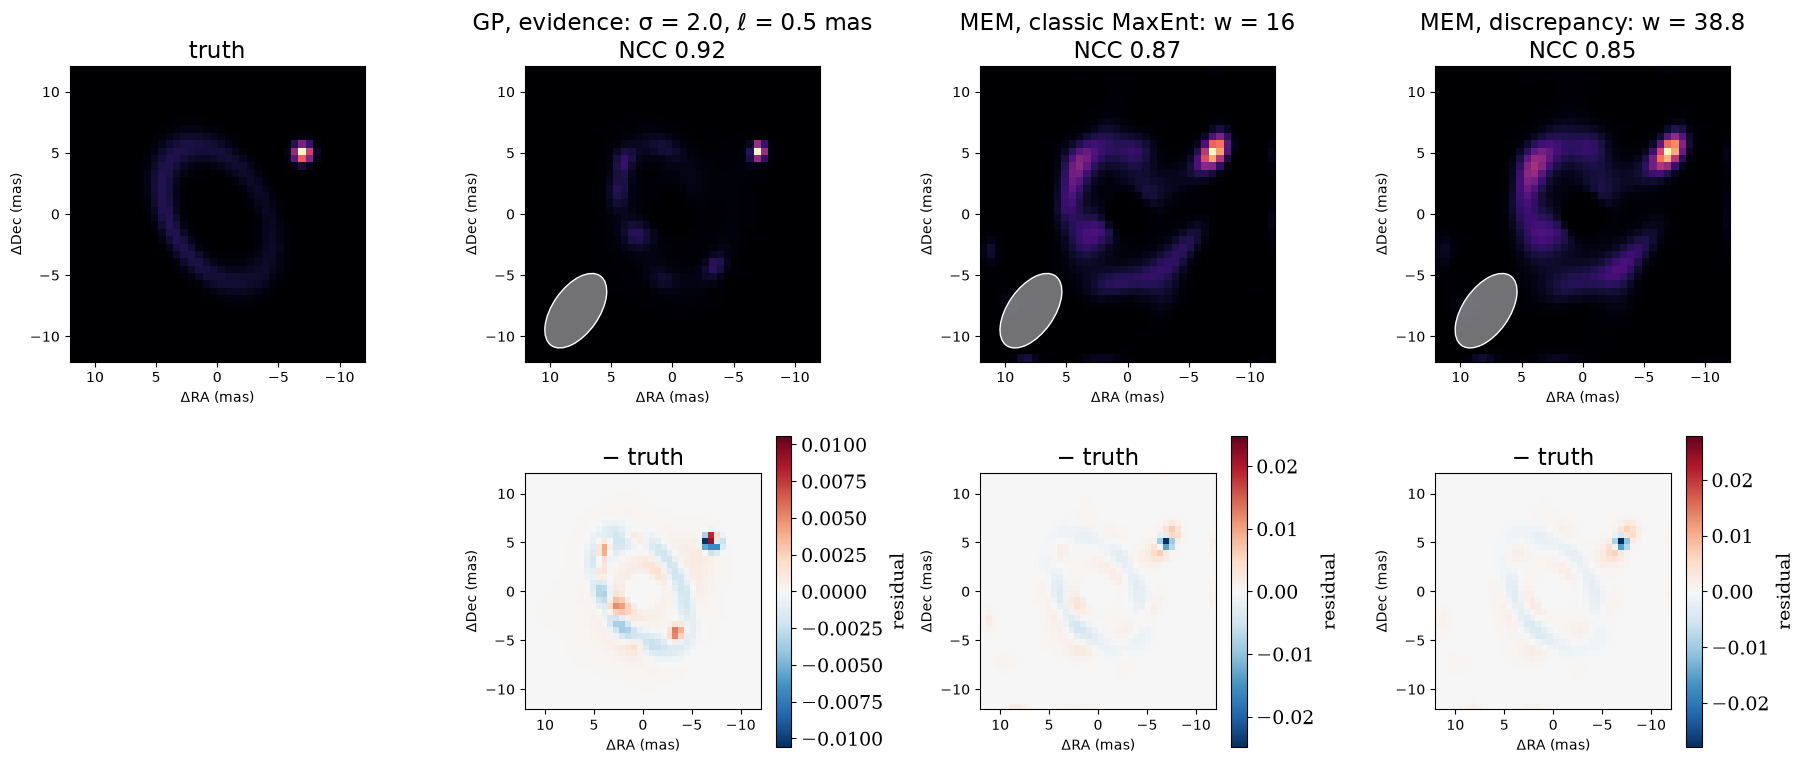

In [4]:
def refit(weight):
    nearest = curve.results[int(jnp.argmin(jnp.abs(jnp.log(curve.weights) - jnp.log(weight))))]
    return fit(mem_start, mem_priors, nights, [MaxEntropy(weight, path="env")], init=nearest.values, max_steps=200_000).model


shown = {
    f"GP, evidence: σ = {sigmas[best[1]]}, ℓ = {lengths[best[0]]} mas": gp[best].model,
    f"MEM, classic MaxEnt: w = {choices['classic MaxEnt']:.3g}": refit(choices["classic MaxEnt"]),
    f"MEM, discrepancy: w = {choices['discrepancy']:.3g}": refit(choices["discrepancy"]),
}
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
plot_model(truth.env, fov_mas=fov, npix=npix, ax=axes[0, 0], title="truth")
axes[1, 0].axis("off")
for column, (name, model) in enumerate(shown.items(), start=1):
    image = model.env.render(npix, fov)
    plot_model(model.env, fov_mas=fov, npix=npix, ax=axes[0, column], title=f"{name}\nNCC {ncc(image, truth_image):.2f}", beam=beam(nights))
    plot_residual_map(image - truth_image, fov_mas=fov, ax=axes[1, column], title="− truth")
plt.tight_layout()
plt.show()

## Summary

On this scene, both evidence-based criteria pick hyperparameters close to the best available, judged against the truth:
- **For the GP prior,** the evidence's maximum over σ and ℓ coincides with, or sits next to, the grid's highest NCC. Each evaluation takes a fraction of a second once the fit is done.
- **For maximum entropy,** classic MaxEnt chooses a smaller weight than the discrepancy principle, nearer the sweep's best fidelity.

Both assume correct error bars, as the discrepancy principle does. With underestimated errors, all three over-regularise. Both also use the Gauss–Newton curvature at the MAP. That is exact for a linear model, and only approximate here, because squared visibilities and closure phases are nonlinear. Sampling the GP image with its hyperparameters (done in the `imaging_sampling` tutorial) avoids the approximation.